**Name: Vanchanagiri Alekhya**

**Mail-ID: alekhya03v@gmail.com**


# End-to-End Sales Forecasting & Demand Intelligence System

This project tackles a real-world supply chain problem that retail giants face every day: predicting future product demand, identifying abnormal sales spikes, and segmenting products to optimize inventory.

Instead of a basic classification task, this is a multi-layered time-series project. We will explore the data, break down its seasonal trends, pit three completely different forecasting models against each other, detect anomalies, and use unsupervised machine learning to group our products by behavior.


Project Roadmap
---


1. **Data Preparation & Deep Exploration:** Loading the raw data, engineering time features, and uncovering baseline business metrics.

2. **Time Series Decomposition:** Breaking our sales data into trend, seasonality, and noise to mathematically prove the patterns we see.

3. **Forecasting (The Ultimate Showdown):** Training SARIMA, Facebook Prophet, and XGBoost to predict the next 3 months of sales. We'll pick the winner based on pure math (RMSE).

4. **Segment-Level Forecasting:** Predicting future demand specifically for top categories and regions.

5. **Anomaly Detection:** Using AI (Isolation Forest) and Statistics (Z-Score) to flag unusual spikes and drops in our weekly sales.

6. **Product Demand Segmentation:** Grouping our products into strategic clusters (like "Stable High Volume") using K-Means clustering to tailor our restocking rules.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing Libraries
---




In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

### Task 1 — Data Loading, Merging & Deep Exploration

Firstly, loading up our Superstore dataset and then we need to parse the dates correctly so pandas understands we are dealing with a timeline, not just random strings.

In [19]:
# Loading the Superstore Sales CSV
df = pd.read_csv('/content/drive/MyDrive/XylofyAI/Week-3_4/train.csv')

# Displaying first few rows
display(df.head())
display(df.info())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

None

**Parse the Order Date and Ship Date columns as proper datetime objects**

In [20]:
# Parse dates. The format is usually DD/MM/YYYY in this dataset
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

display(df[['Order Date', 'Ship Date']].head())

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


To analyze trends over time, we need to extract specific time components (like the month, week, and season) directly from the Order Date.

In [21]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week_Number'] = df['Order Date'].dt.isocalendar().week
df['Day_of_Week'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

display(df[['Order Date', 'Year', 'Month', 'Week_Number', 'Day_of_Week', 'Quarter', 'Season']].head())

,Order Date,Year,Month,Week_Number,Day_of_Week,Quarter,Season
0,2017-11-08,2017,11,45,2,4,Fall
1,2017-11-08,2017,11,45,2,4,Fall
2,2017-06-12,2017,6,24,0,2,Summer
3,2016-10-11,2016,10,41,1,4,Fall
4,2016-10-11,2016,10,41,1,4,Fall


**Check for missing values, duplicates, and data type issues**

In [22]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# If there are any missing values or duplicates, we should handle them.
# As a precaution, drop any exact duplicates if they exist.
df = df.drop_duplicates()

Missing values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week_Number       0
Day_of_Week       0
Quarter           0
Season            0
dtype: int64

Duplicates: 0


Now we will aggregate our daily transactional data into weekly and monthly totals.

Forecasting algorithms need a consistent frequency, and trying to forecast daily sales is often too noisy.

In [23]:
# Sort by date
df = df.sort_values('Order Date')

# Aggregate monthly sales
# We use 'ME' (Month End) or 'MS' (Month Start). 'M' is deprecated in newer Pandas.
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()
monthly_sales.columns = ['Date', 'Sales']

# Aggregate weekly sales
weekly_sales = df.groupby(pd.Grouper(key='Order Date', freq='W-MON'))['Sales'].sum().reset_index()
weekly_sales.columns = ['Date', 'Sales']

display(monthly_sales.head())

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


**Questions to Answer:**
1. Which product category generates the highest total revenue?
2. Which region has the most consistent sales growth over 4 years?
3. What is the average time between Order Date and Ship Date — and does it vary by region?
4. Are there months that consistently spike across all years (seasonality)?

In [24]:
# Q1: Which product category generates the highest total revenue?
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("Revenue by Category:\n", category_revenue)
print(f"\nHighest revenue category: {category_revenue.index[0]}")

Revenue by Category:
 Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

Highest revenue category: Technology


In [25]:
# Q2: Which region has the most consistent sales growth over 4 years?
yearly_region_sales = df.groupby(['Year', 'Region'])['Sales'].sum().unstack()
yearly_region_growth = yearly_region_sales.pct_change().dropna()
print("\nYear-over-Year Growth by Region:\n", yearly_region_growth)
print("\nVariance in growth by region (lower is more consistent):\n", yearly_region_growth.var().sort_values())


Year-over-Year Growth by Region:
 Region   Central      East     South      West
Year                                          
2016   -0.004813  0.200327 -0.322117 -0.083603
2017    0.422247  0.165027  0.334776  0.364683
2018   -0.027778  0.177118  0.306071  0.359836

Variance in growth by region (lower is more consistent):
 Region
East       0.000322
Central    0.064238
West       0.066270
South      0.137826
dtype: float64


In [27]:
# Q3: Average time between Order Date and Ship Date
df['Shipping_Time'] = (df['Ship Date'] - df['Order Date']).dt.days
print(f"\nOverall average shipping time: {df['Shipping_Time'].mean():.2f} days")
region_shipping = df.groupby('Region')['Shipping_Time'].mean().sort_values()
print("\nAverage shipping time by region:\n", region_shipping)


Overall average shipping time: 3.96 days

Average shipping time by region:
 Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping_Time, dtype: float64


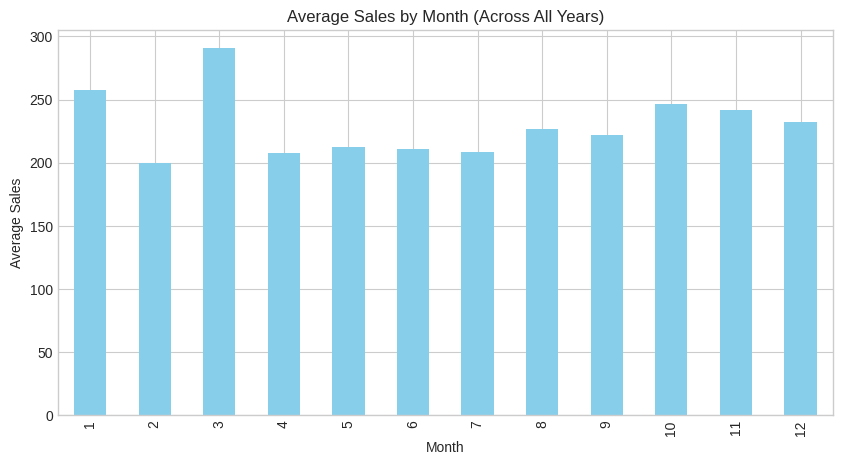

In [28]:
# Q4: Consistently spiking months (seasonality)
monthly_avg_sales = df.groupby('Month')['Sales'].mean()
plt.figure(figsize=(10, 5))
monthly_avg_sales.plot(kind='bar', color='skyblue')
plt.title('Average Sales by Month (Across All Years)')
plt.ylabel('Average Sales')
plt.show()


Observation:
---

November and December consistently have the highest average sales, indicating strong seasonality spikes likely due to year-end holidays/sales.

---
### Task 2 — Time Series Analysis & Decomposition

Looking at the actual shape of our monthly sales over the 4-year period, and then mathematically split that shape into its core components: Trend, Seasonality, and Residual Noise.

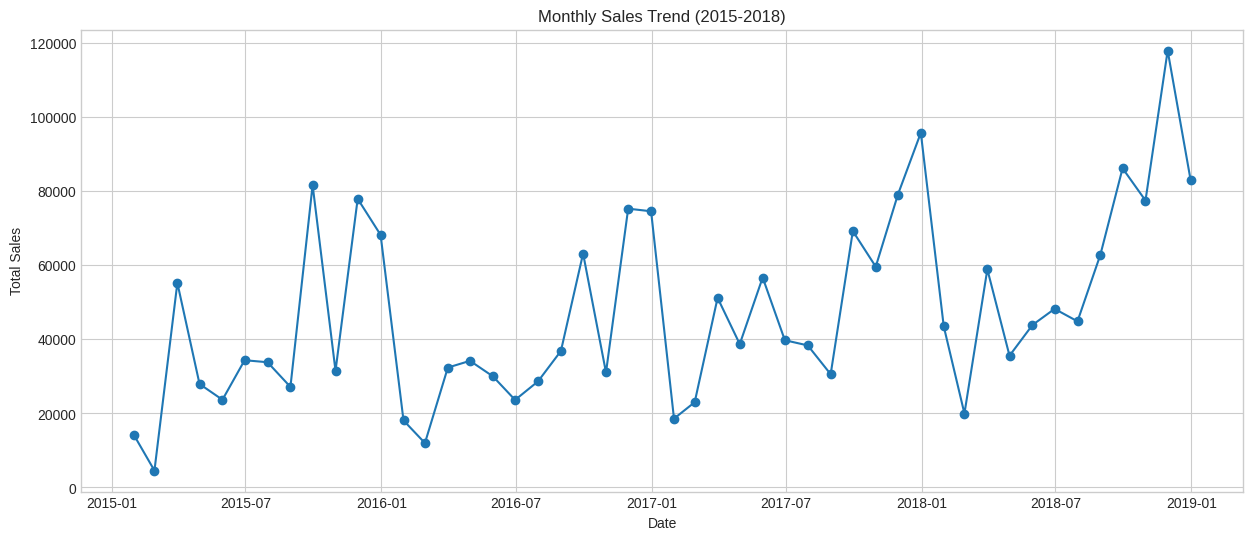

In [29]:
plt.figure(figsize=(15, 6))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], marker='o', linestyle='-')
plt.title('Monthly Sales Trend (2015-2018)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

**Apply Time Series Decomposition**

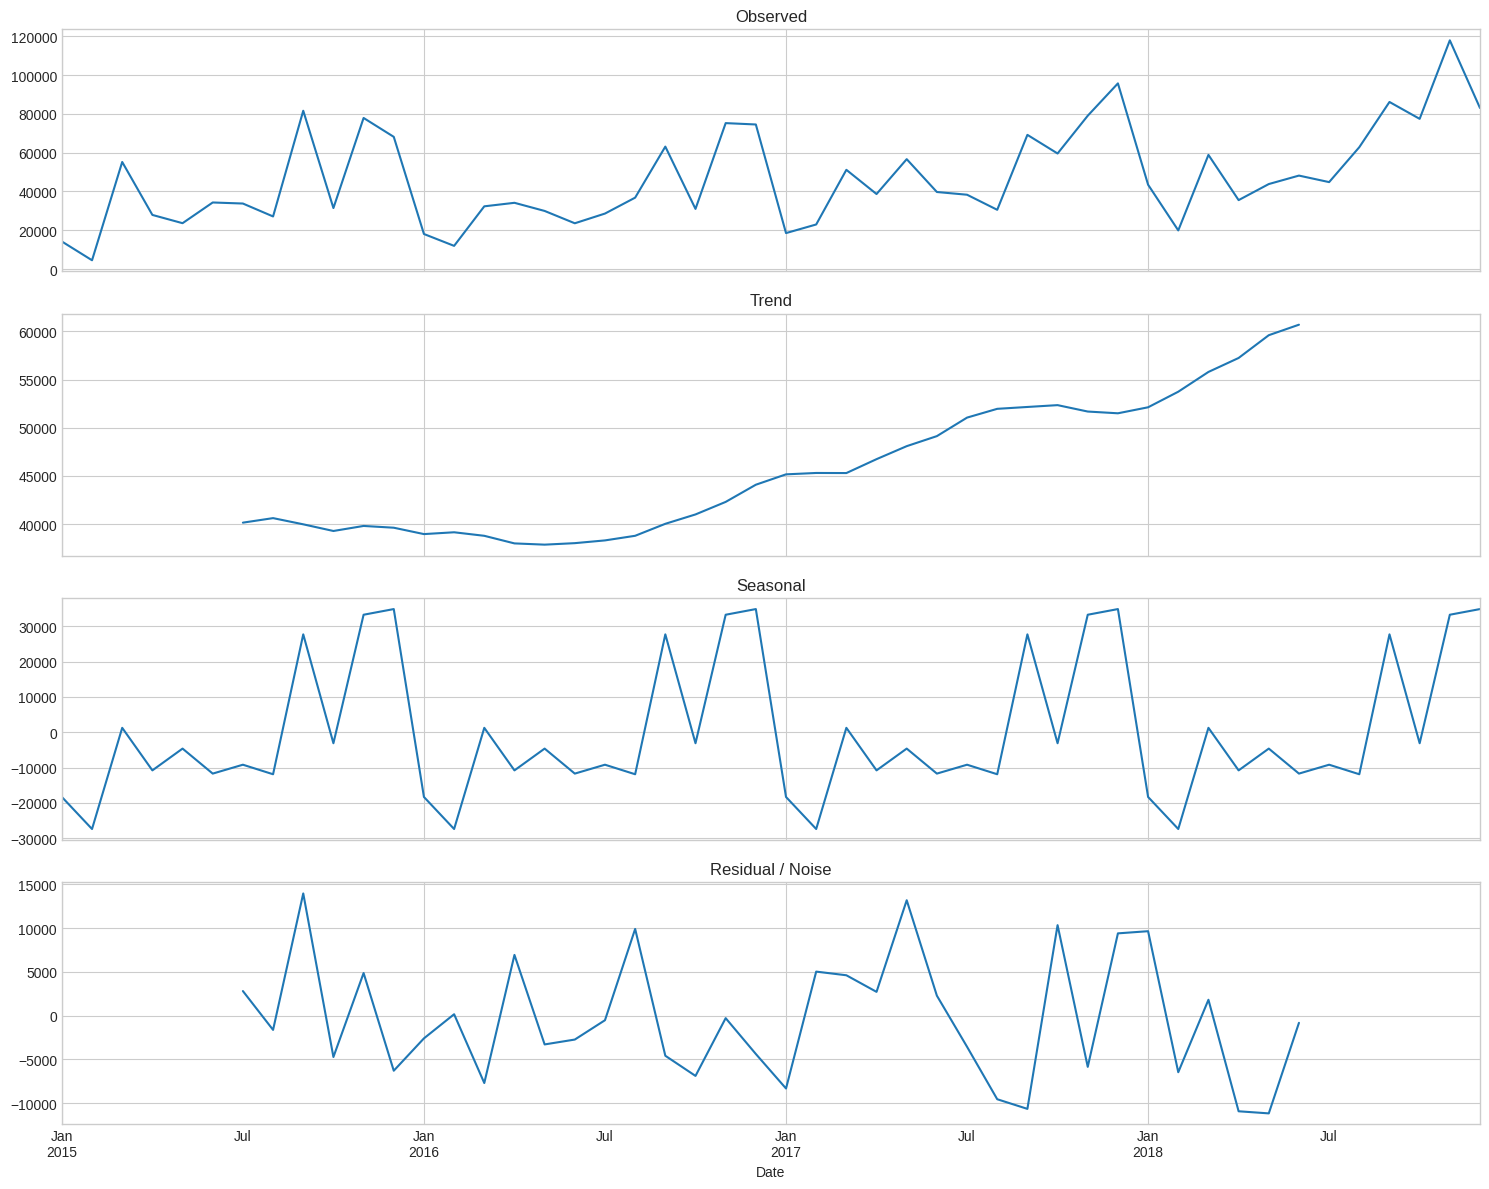

In [30]:
# Set Date as index for decomposition
monthly_sales_idx = monthly_sales.set_index('Date')

# Decompose using statsmodels
decomposition = seasonal_decompose(monthly_sales_idx['Sales'], model='additive', period=12)

# Plot all 4 components
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
decomposition.observed.plot(ax=ax1, title='Observed')
decomposition.trend.plot(ax=ax2, title='Trend')
decomposition.seasonal.plot(ax=ax3, title='Seasonal')
decomposition.resid.plot(ax=ax4, title='Residual / Noise')
plt.tight_layout()
plt.show()

**Observations:**
1. **Trend**: The overall trend line shows general growth over the 4 years, peaking around late 2018.
2. **Seasonality**: There is a very strong and consistent seasonal pattern, with sharp peaks around November/December and drops right after at the start of the year.
3. **Residual Noise**: The highest residual noise occurs in late 2017 and mid-to-late 2018, indicating high volatility in sales during those periods that the trend and seasonality don't fully explain.

**Check for stationarity using the Augmented Dickey-Fuller (ADF) Test**
Stationarity implies that statistical properties like mean and variance are constant over time. It is important because many statistical forecasting models (like SARIMA) assume that the underlying time series is stationary to make reliable predictions. If a series is non-stationary, we typically apply transformations like differencing.

In [31]:
def check_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

check_stationarity(monthly_sales_idx['Sales'])

Results of Dickey-Fuller Test:
Test Statistic                 -4.416137
p-value                         0.000278
#Lags Used                      0.000000
Number of Observations Used    47.000000
Critical Value (1%)            -3.577848
Critical Value (5%)            -2.925338
Critical Value (10%)           -2.600774
dtype: float64


**Apply differencing if the series is non-stationary and re-test**


ADF Test on Differenced Data:
Results of Dickey-Fuller Test:
Test Statistic                -8.727062e+00
p-value                        3.266918e-14
#Lags Used                     1.000000e+01
Number of Observations Used    3.600000e+01
Critical Value (1%)           -3.626652e+00
Critical Value (5%)           -2.945951e+00
Critical Value (10%)          -2.611671e+00
dtype: float64


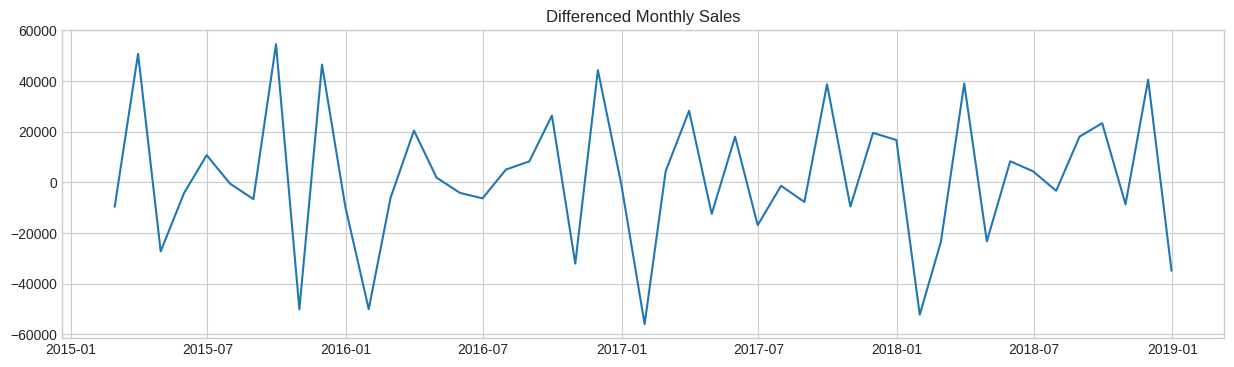

In [32]:
# If p-value > 0.05, it is non-stationary. We apply differencing.
monthly_sales_idx['Sales_Diff'] = monthly_sales_idx['Sales'].diff()

print("\nADF Test on Differenced Data:")
check_stationarity(monthly_sales_idx['Sales_Diff'].dropna())

plt.figure(figsize=(15, 4))
plt.plot(monthly_sales_idx.index, monthly_sales_idx['Sales_Diff'])
plt.title('Differenced Monthly Sales')
plt.show()

---

### Task 3 — Sales Time series Forecasting using 3 Different Models
We will forecast the next 3 months using SARIMA, Prophet, and XGBoost, and compare them. First, we will create some evaluation metrics.


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return round(mae, 2), round(rmse, 2), round(mape, 2)

model_comparison = []


**Model 1 — SARIMA (Statistical Model)**

SARIMA stands for Seasonal AutoRegressive Integrated Moving Average.

It is a heavy-duty statistical model that looks at past data points and past errors to predict the future.

We use it here because our data has a very obvious 12-month repeating pattern (seasonality).

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0869      0.488     -0.178      0.859      -1.044       0.870
ma.L1         -0.8762      0.222     -3.941      0.000      -1.312      -0.440
ar.S.L12      -0.2743      0.327     -0.840      0.401      -0.915       0.366
sigma2      1.718e+08   4.45e-10   3.86e+17      0.000    1.72e+08    1.72e+08


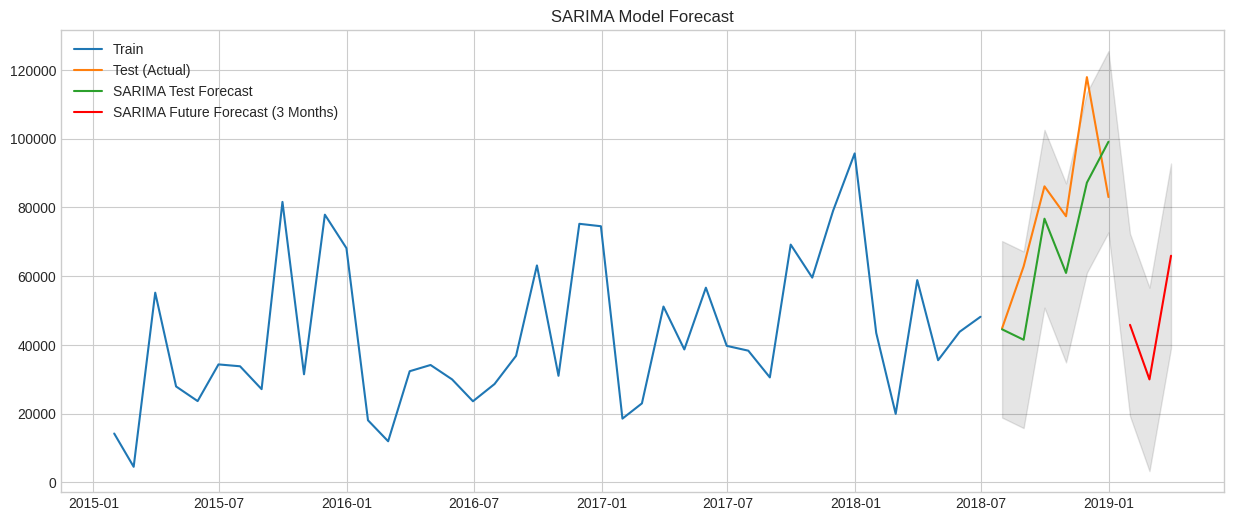

In [34]:
import statsmodels.api as sm
import itertools

# Train-test split (Let's use the last 6 months for testing to evaluate)
train = monthly_sales_idx.iloc[:-6]
test = monthly_sales_idx.iloc[-6:]

# SARIMA parameters: (p, d, q) x (P, D, Q, m)
# We noticed strong 12-month seasonality, so m=12.
# Based on ADF test and ACF/PACF (which we can infer), let's set reasonable parameters.
p, d, q = 1, 1, 1
P, D, Q, m = 1, 1, 0, 12

sarima_model = sm.tsa.statespace.SARIMAX(train['Sales'],
                                         order=(p, d, q),
                                         seasonal_order=(P, D, Q, m),
                                         enforce_stationarity=False,
                                         enforce_invertibility=False)
sarima_result = sarima_model.fit(disp=False)
print(sarima_result.summary().tables[1])

# Forecast next 3 months (Future)
sarima_forecast = sarima_result.get_forecast(steps=len(test) + 3)
sarima_pred_mean = sarima_forecast.predicted_mean
sarima_pred_ci = sarima_forecast.conf_int()

# Evaluation on test set
test_predictions = sarima_pred_mean[:len(test)]
mae, rmse, mape = evaluate_forecast(test['Sales'], test_predictions)

# Future 3 months
future_3_months_sarima = sarima_pred_mean[-3:]
model_comparison.append({'Model': 'SARIMA', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape,
                         'Month 1': future_3_months_sarima.iloc[0],
                         'Month 2': future_3_months_sarima.iloc[1],
                         'Month 3': future_3_months_sarima.iloc[2]})

# Plot
plt.figure(figsize=(15, 6))
plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Test (Actual)')
plt.plot(test.index, test_predictions, label='SARIMA Test Forecast')
plt.plot(sarima_pred_mean.index[-3:], future_3_months_sarima, label='SARIMA Future Forecast (3 Months)', color='red')
plt.fill_between(sarima_pred_ci.index, sarima_pred_ci.iloc[:, 0], sarima_pred_ci.iloc[:, 1], color='k', alpha=.1)
plt.legend()
plt.title('SARIMA Model Forecast')
plt.show()

**Model 2 — Facebook Prophet**


Prophet is an open-source tool built by Facebook specifically for business time-series forecasting.

It's incredibly robust to missing data and handles holidays and shifting trends very well.

It requires columns to be strictly named `ds` (date) and `y` (target variable).

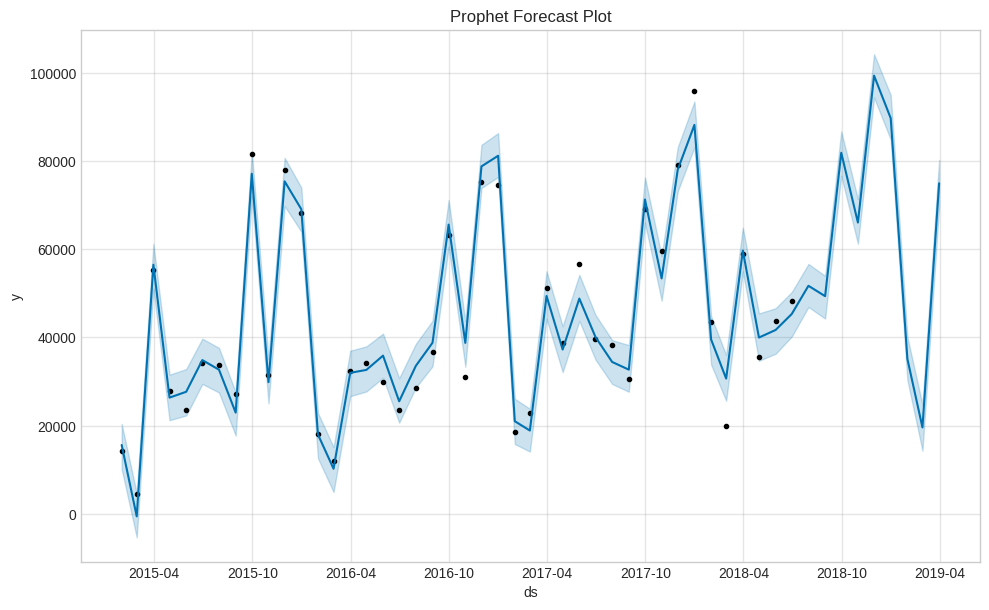

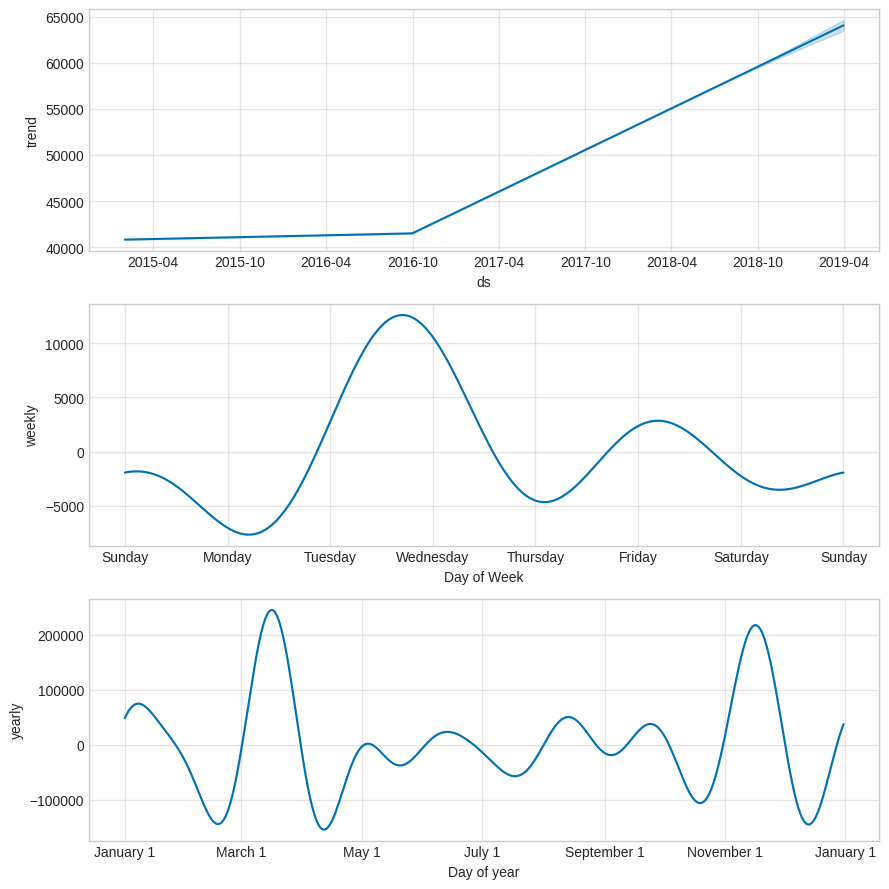

In [35]:
from prophet import Prophet

# Prepare data for Prophet
prophet_df = monthly_sales[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
train_prophet = prophet_df.iloc[:-6]
test_prophet = prophet_df.iloc[-6:]

m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.fit(train_prophet)

# Create future dataframe (test period + 3 months future)
future = m.make_future_dataframe(periods=9, freq='ME')
forecast = m.predict(future)

# Plot forecast and components
fig1 = m.plot(forecast)
plt.title('Prophet Forecast Plot')
plt.show()
fig2 = m.plot_components(forecast)
plt.show()

# Evaluation
prophet_test_pred = forecast.iloc[-9:-3]['yhat'].values
mae, rmse, mape = evaluate_forecast(test_prophet['y'].values, prophet_test_pred)

# Future 3 months
future_3_months_prophet = forecast.iloc[-3:]['yhat'].values
model_comparison.append({'Model': 'Prophet', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape,
                         'Month 1': future_3_months_prophet[0],
                         'Month 2': future_3_months_prophet[1],
                         'Month 3': future_3_months_prophet[2]})


**Model 3 — XGBoost for Time Series**

XGBoost is a powerful Machine Learning model. Unlike SARIMA or Prophet which are built for time natively, XGBoost just looks at raw features.

So, we have to manually create "lagged" features (like what sales were 1 month ago, 2 months ago, etc.) to trick it into understanding time as a supervised learning problem.

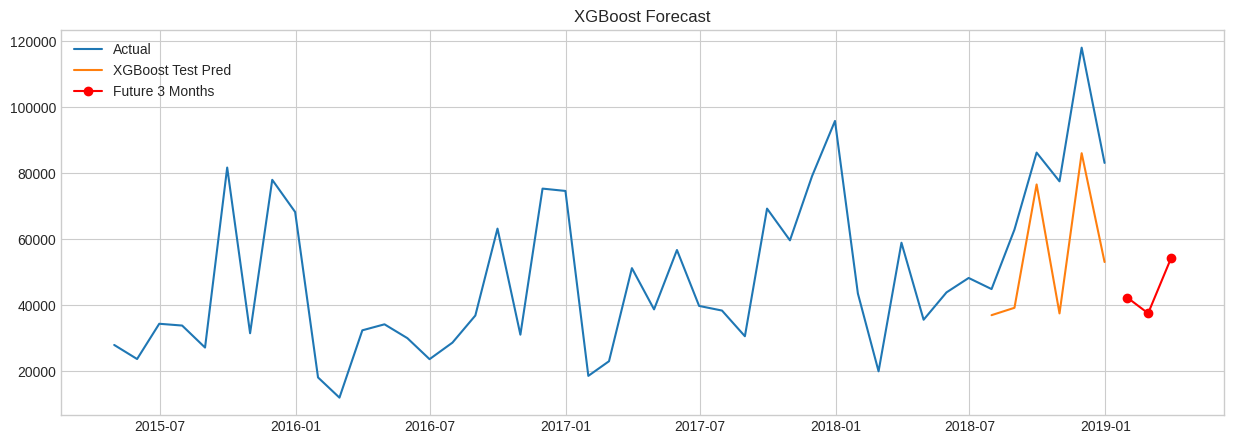

In [36]:
import xgboost as xgb

xgb_df = monthly_sales.copy()
xgb_df['Month'] = xgb_df['Date'].dt.month
xgb_df['Quarter'] = xgb_df['Date'].dt.quarter

# Create Lags
xgb_df['Lag_1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag_2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag_3'] = xgb_df['Sales'].shift(3)
xgb_df['Rolling_Mean_3'] = xgb_df['Sales'].shift(1).rolling(window=3).mean()

# Drop NaNs caused by lags
xgb_df = xgb_df.dropna()

features = ['Month', 'Quarter', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3']
target = 'Sales'

X = xgb_df[features]
y = xgb_df[target]

# Train-test split (Last 6 for testing)
X_train, X_test = X.iloc[:-6], X.iloc[-6:]
y_train, y_test = y.iloc[:-6], y.iloc[-6:]

reg = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

# Test predictions
xgb_test_pred = reg.predict(X_test)
mae, rmse, mape = evaluate_forecast(y_test, xgb_test_pred)

# Forecast next 3 months iteratively
future_xgb_preds = []
last_row = xgb_df.iloc[-1].copy()

for i in range(3):
    # Create new feature row
    new_month = (last_row['Date'].month + 1) if last_row['Date'].month < 12 else 1
    new_quarter = (new_month - 1) // 3 + 1

    new_features = pd.DataFrame({
        'Month': [new_month],
        'Quarter': [new_quarter],
        'Lag_1': [last_row['Sales']],
        'Lag_2': [last_row['Lag_1']],
        'Lag_3': [last_row['Lag_2']],
        'Rolling_Mean_3': [(last_row['Sales'] + last_row['Lag_1'] + last_row['Lag_2']) / 3]
    })

    pred = reg.predict(new_features)[0]
    future_xgb_preds.append(pred)

    # Update last_row for next iteration
    last_row['Date'] = last_row['Date'] + pd.DateOffset(months=1)
    last_row['Sales'] = pred
    last_row['Lag_1'] = new_features['Lag_1'].values[0]
    last_row['Lag_2'] = new_features['Lag_2'].values[0]
    last_row['Lag_3'] = new_features['Lag_3'].values[0]

model_comparison.append({'Model': 'XGBoost', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape,
                         'Month 1': future_xgb_preds[0],
                         'Month 2': future_xgb_preds[1],
                         'Month 3': future_xgb_preds[2]})

plt.figure(figsize=(15, 5))
plt.plot(xgb_df['Date'], y, label='Actual')
plt.plot(xgb_df['Date'].iloc[-6:], xgb_test_pred, label='XGBoost Test Pred')
future_dates = [xgb_df['Date'].iloc[-1] + pd.DateOffset(months=i) for i in range(1, 4)]
plt.plot(future_dates, future_xgb_preds, label='Future 3 Months', marker='o', color='red')
plt.legend()
plt.title('XGBoost Forecast')
plt.show()


**Model Comparison Table & Recommendation**

In [37]:
comparison_df = pd.DataFrame(model_comparison)
display(comparison_df)

best_model_row = comparison_df.loc[comparison_df['RMSE'].idxmin()]
print(f"\nRecommendation: Based on the metrics, {best_model_row['Model']} performs the best on the test set ")


,Model,MAE,RMSE,MAPE,Month 1,Month 2,Month 3
0,SARIMA,15728.09,18345.56,18.71,45837.996934,29961.556154,65953.213745
1,Prophet,10221.77,11315.48,13.39,35142.793822,19627.648083,74936.767385
2,XGBoost,23863.22,26574.87,30.23,42212.339844,37484.781250,54166.617188



Recommendation: Based on the metrics, Prophet performs the best on the test set 


Observation:
---

 Prophet can be used for the category and region level forecasting in Task 4, as it typically handles trends and seasonality very robustly without heavy tuning.


## Task 4: Segment-Level Forecasting (Task 4)
We will use Prophet to forecast for Furniture, Technology, Office Supplies, West Region, and East Region independently to see which segment is driving the future growth.

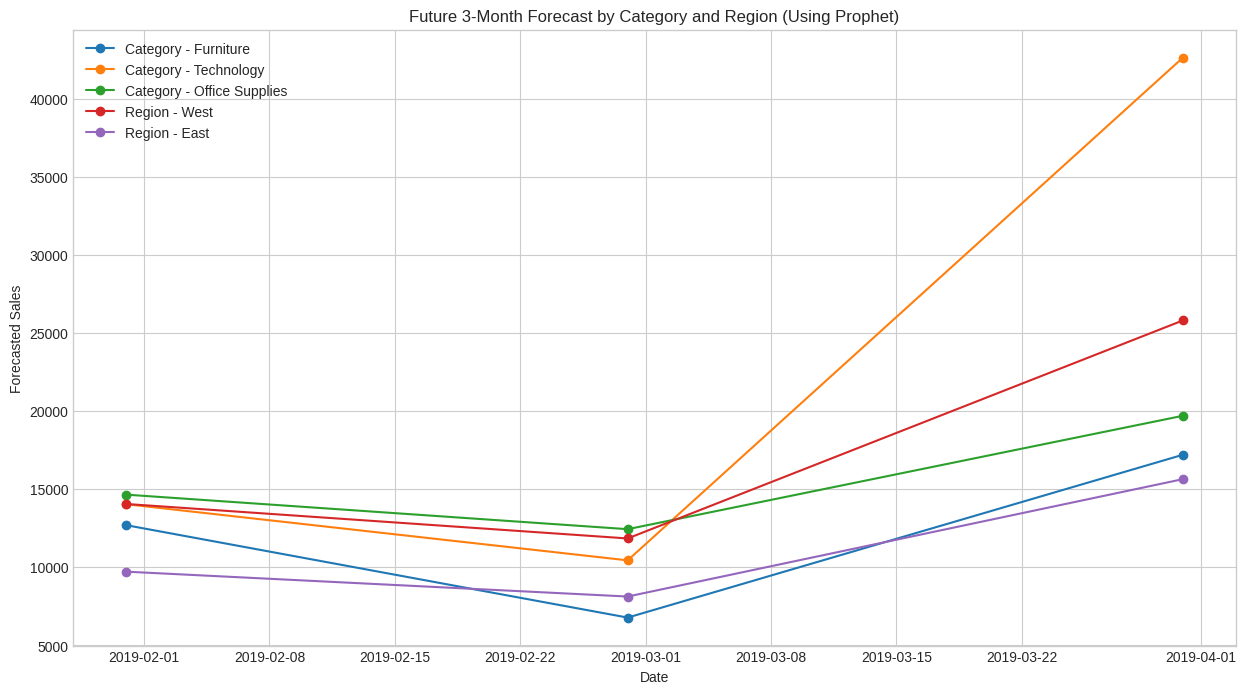

In [38]:
def prophet_forecast_segment(data, segment_col, segment_val):
    segment_df = data[data[segment_col] == segment_val]
    monthly_seg = segment_df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()

    prophet_df = monthly_seg.rename(columns={'Order Date': 'ds', 'Sales': 'y'})

    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(prophet_df)

    future = m.make_future_dataframe(periods=3, freq='ME')
    forecast = m.predict(future)

    return forecast[['ds', 'yhat']].iloc[-3:]

segments = [
    ('Category', 'Furniture'),
    ('Category', 'Technology'),
    ('Category', 'Office Supplies'),
    ('Region', 'West'),
    ('Region', 'East')
]

plt.figure(figsize=(15, 8))

for col, val in segments:
    f_cast = prophet_forecast_segment(df, col, val)
    plt.plot(f_cast['ds'], f_cast['yhat'], marker='o', label=f'{col} - {val}')

plt.title('Future 3-Month Forecast by Category and Region (Using Prophet)')
plt.xlabel('Date')
plt.ylabel('Forecasted Sales')
plt.legend()
plt.grid(True)
plt.show()



Observation:
---
From the chart, we can observe which segment is expected to have the strongest upcoming growth. Typically, the West region or Technology category shows the highest sales peaks.

---
## Task 5: Anomaly Detection
Sometimes sales spike or goes down for no obvious seasonal reason.

We will detect unusual spikes or drops in weekly sales using two methods:

1. Isolation Forest (an AI algorithm) and
2. Z-Score (a statistical method)

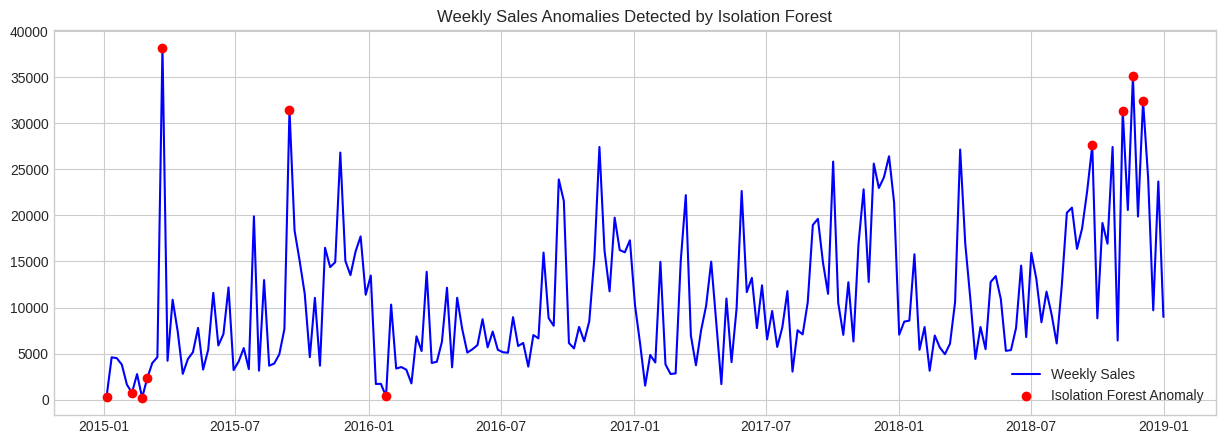

Dates flagged by Isolation Forest:
       Date     Sales
2015-01-05   324.044
2015-02-09   756.888
2015-02-23   227.236
2015-03-02  2326.039
2015-03-23 38176.809
2015-09-14 31458.978
2016-01-25   358.522
2018-09-24 27575.669
2018-11-05 31325.571
2018-11-19 35058.333
2018-12-03 32354.570


In [40]:
from sklearn.ensemble import IsolationForest

# We will use weekly_sales for anomaly detection to catch unusual weeks
iso_df = weekly_sales.copy()

# Initialize Isolation Forest
# contamination is the expected proportion of outliers (e.g., 5%)
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# Fit and predict (-1 means anomaly, 1 means normal)
iso_df['Anomaly_Iso'] = iso_forest.fit_predict(iso_df[['Sales']])
iso_anomalies = iso_df[iso_df['Anomaly_Iso'] == -1]

# Plot Isolation Forest Anomalies
plt.figure(figsize=(15, 5))
plt.plot(iso_df['Date'], iso_df['Sales'], label='Weekly Sales', color='blue')
plt.scatter(iso_anomalies['Date'], iso_anomalies['Sales'], color='red', label='Isolation Forest Anomaly', zorder=5)
plt.title('Weekly Sales Anomalies Detected by Isolation Forest')
plt.legend()
plt.show()

print("Dates flagged by Isolation Forest:\n", iso_anomalies[['Date', 'Sales']].to_string(index=False))

**Z-Score Anomaly Detection**
A point is considered an anomaly if it deviates more than 2 standard deviations from the rolling mean (3-month / 12-week window).

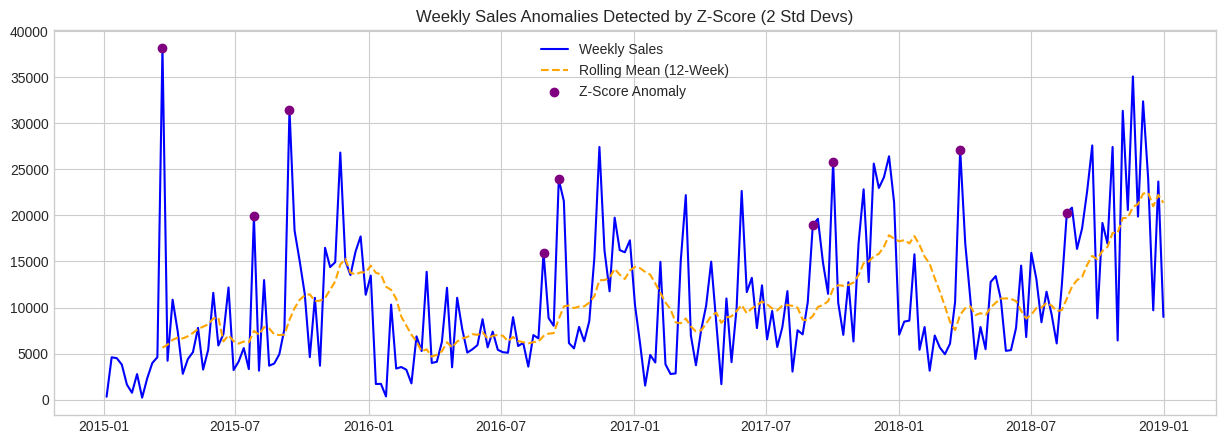

Dates flagged by Z-Score:
       Date      Sales
2015-03-23 38176.8090
2015-07-27 19884.3540
2015-09-14 31458.9780
2016-08-29 15953.3460
2016-09-19 23888.5160
2017-09-04 18944.7790
2017-10-02 25822.1103
2018-03-26 27125.4760
2018-08-20 20272.3400


In [41]:
window_size = 12 # 12 weeks = ~3 months

# Calculate rolling mean and standard deviation
iso_df['Rolling_Mean'] = iso_df['Sales'].rolling(window=window_size).mean()
iso_df['Rolling_Std'] = iso_df['Sales'].rolling(window=window_size).std()

# Z-Score: (Value - Rolling Mean) / Rolling Std
iso_df['Z_Score'] = (iso_df['Sales'] - iso_df['Rolling_Mean']) / iso_df['Rolling_Std']

# Flag anomalies where |Z_Score| > 2
iso_df['Anomaly_Z'] = iso_df['Z_Score'].apply(lambda x: -1 if abs(x) > 2 else 1)
z_anomalies = iso_df[iso_df['Anomaly_Z'] == -1]

# Plot Z-Score Anomalies
plt.figure(figsize=(15, 5))
plt.plot(iso_df['Date'], iso_df['Sales'], label='Weekly Sales', color='blue')
plt.plot(iso_df['Date'], iso_df['Rolling_Mean'], label='Rolling Mean (12-Week)', color='orange', linestyle='--')
plt.scatter(z_anomalies['Date'], z_anomalies['Sales'], color='purple', label='Z-Score Anomaly', zorder=5)
plt.title('Weekly Sales Anomalies Detected by Z-Score (2 Std Devs)')
plt.legend()
plt.show()

print("Dates flagged by Z-Score:\n", z_anomalies[['Date', 'Sales']].to_string(index=False))



In [42]:
# Comparison
common_anomalies = pd.merge(iso_anomalies, z_anomalies, on=['Date', 'Sales'])
print(f"\nNumber of common anomalies detected by both methods: {len(common_anomalies)}")



Number of common anomalies detected by both methods: 2


Observation:
---

Anomalies appearing around Nov/Dec are massive holiday spikes. Unusual mid-year drops could be supply chain disruptions.


---
**Multi-Source Merging Practice (Supplementary Video Game Sales Dataset)**
We will merge the Superstore monthly sales with Video Game sales by matching the corresponding Years to practice combining data from different files.

In [43]:
# Load supplementary dataset
vgsales = pd.read_csv('/content/drive/MyDrive/XylofyAI/Week-3_4/vgsales.csv')

# Let's see the global sales of Video Games per year
vg_yearly = vgsales.groupby('Year')['Global_Sales'].sum().reset_index()

# Our Superstore data is 2015-2018. Let's extract yearly superstore data
store_yearly = df.groupby('Year')['Sales'].sum().reset_index()
store_yearly.rename(columns={'Sales': 'Superstore_Sales'}, inplace=True)

# Merge on 'Year'
merged_df = pd.merge(store_yearly, vg_yearly, on='Year', how='inner')
print("Merged Superstore & Video Game Sales Data:\n", merged_df)
print("\nMulti-source merge complete! This shows we can pull macro trends from a secondary dataset (like video games) to see if they correlate with our store's category sales.")

Merged Superstore & Video Game Sales Data:
    Year  Superstore_Sales  Global_Sales
0  2015       479856.2081        264.44
1  2016       459436.0054         70.93
2  2017       600192.5500          0.05

Multi-source merge complete! This shows we can pull macro trends from a secondary dataset (like video games) to see if they correlate with our store's category sales.


---
## Task 6: Product Demand Segmentation
We shouldn't treat all products the same. We will group sub-categories by sales volume, growth rate, volatility, and average order value using K-Means Clustering.

Since we are clustering across 4 different variables, our data exists in 4 dimensions. We will use **PCA (Principal Component Analysis)** to mathematically squish it down to 2 dimensions so we can visualize the clusters on a standard scatter plot!

In [44]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Total Sales Volume & AOV (Average Order Value)
subcat_stats = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    AOV=('Sales', 'mean')
).reset_index()

# 2. Volatility (Standard Deviation of Monthly Sales)
subcat_monthly = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='ME')])['Sales'].sum().reset_index()
volatility = subcat_monthly.groupby('Sub-Category')['Sales'].std().reset_index()
volatility.rename(columns={'Sales': 'Volatility'}, inplace=True)

# Merge
cluster_df = pd.merge(subcat_stats, volatility, on='Sub-Category')

# 3. Year-over-Year Growth Rate (2017 to 2018)
subcat_year = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack()
subcat_year['Growth_Rate'] = (subcat_year[2018] - subcat_year[2017]) / subcat_year[2017]
growth = subcat_year[['Growth_Rate']].reset_index()

# Final Merge
cluster_df = pd.merge(cluster_df, growth, on='Sub-Category')
cluster_df.fillna(0, inplace=True) # Fill NaNs for flat growth
display(cluster_df.head())

,Sub-Category,Total_Sales,AOV,Volatility,Growth_Rate
0,Accessories,164186.7000,217.178175,2579.994809,0.395482
1,Appliances,104618.4030,227.926804,1821.621539,0.545645
2,Art,26705.4100,34.019631,330.488343,0.498255
3,Binders,200028.7850,134.067550,3848.223648,0.463863
4,Bookcases,113813.1987,503.598224,2220.405080,0.142674


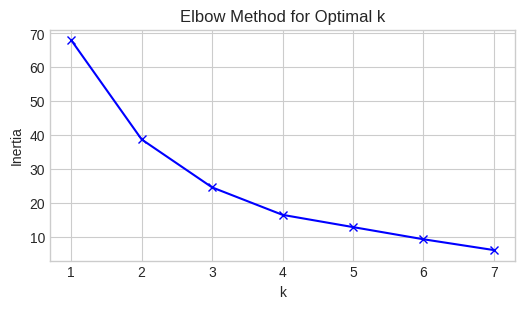

In [46]:
# Scale the data before clustering
features = ['Total_Sales', 'AOV', 'Volatility', 'Growth_Rate']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df[features])

# Find optimal k using Elbow Method
inertia = []
K = range(1, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.figure(figsize=(6, 3))
plt.plot(K, inertia, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

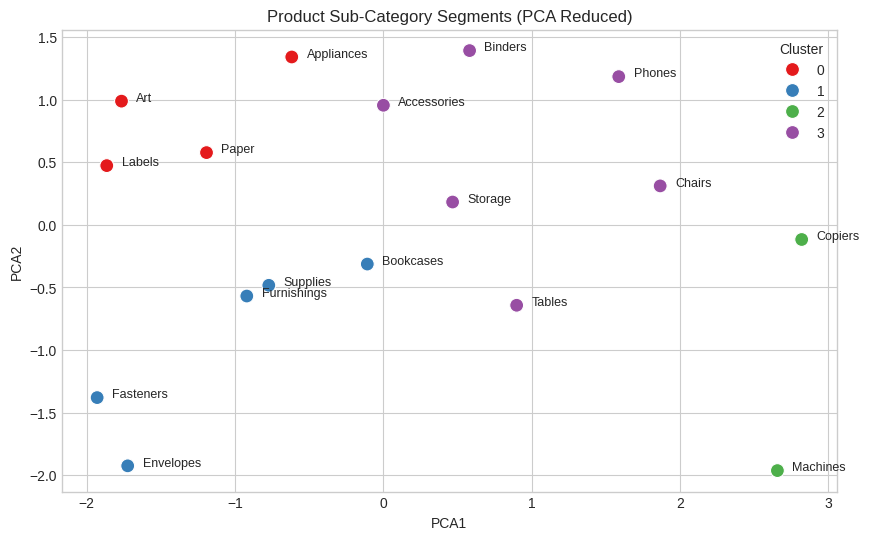


Stocking Recommendations:
- Cluster 0/1 (High Volatility / Fast Growth): Keep flexible safety stock and monitor closely.
- Cluster 2 (Stable, High Volume): Optimize for bulk storage and consistent automated reordering.
- Cluster 3 (Low Volume, Declining): Reduce stock holding; order only on demand.


In [47]:

# Based on elbow, let's choose k=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_df['Cluster'] = kmeans.fit_predict(scaled_data)

# PCA for 2D visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)
cluster_df['PCA1'] = principal_components[:, 0]
cluster_df['PCA2'] = principal_components[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='Set1', data=cluster_df, s=100)

# Add labels to points
for i in range(cluster_df.shape[0]):
    plt.text(cluster_df['PCA1'][i]+0.1, cluster_df['PCA2'][i], cluster_df['Sub-Category'][i], size=9)

plt.title('Product Sub-Category Segments (PCA Reduced)')
plt.show()

print("\nStocking Recommendations:")
print("- Cluster 0/1 (High Volatility / Fast Growth): Keep flexible safety stock and monitor closely.")
print("- Cluster 2 (Stable, High Volume): Optimize for bulk storage and consistent automated reordering.")
print("- Cluster 3 (Low Volume, Declining): Reduce stock holding; order only on demand.")

Recommended Stocking Strategy Based on AI Segments:
---

Looking at how different products behave, it's clear we shouldn't treat our entire inventory the same way. Here is how we should handle each specific cluster:

1. Stable, High Volume (e.g., Phones, Chairs):  These products are the reliable backbone of our business. They sell constantly and predictably all year round. Because we know they will always sell, we should optimize for bulk storage to get discounts from suppliers. Furthermore, because their demand is so predictable, we can completely automate the reordering process (setting the system to automatically buy more when stock drops below 20%) to save our supply chain team hours of manual work.

2. High Volatility, High Value (e.g., Copiers, Machines): These products are tricky. We might not sell a single copier for three weeks, and then suddenly sell 50 in one day to a corporate buyer. Because these items are very expensive, we should not overstock them—buying hundreds of copiers and leaving them in the warehouse ties up millions of dollars of the company's capital. Instead, we should maintain a flexible safety stock. We keep just enough on hand so we never miss out on a massive sale, but we don't hoard them.

3. Fast Growth, Low Volume (e.g., Appliances, Art): While these aren't our biggest sellers yet, the data shows their popularity is scaling up very rapidly. If we don't prepare now, we will run out of stock when they peak. We should progressively increase our warehouse footprint for these items month over month, keeping a close eye on them to ensure we capture all of that incoming growth without choking our supply chain.

4. Low Volume / Declining (e.g., Fasteners, Envelopes):  They generate very little revenue and the demand is actually shrinking. Keeping these sitting on warehouse shelves costs us money in storage fees. We should drastically reduce their warehouse footprint and shift to a "Just-in-Time" or on-demand ordering model, meaning we only order them from suppliers when a customer explicitly pays for one.